In [25]:
import lightgbm as lgb
import pandas as pd
import mlflow
from smart_goals.predict import load_data
from snowflake.snowpark import Session
import matplotlib.pyplot as plt

In [26]:
MODEL_NAME = "smart_goals"
TARGET_COL = "SALES_PER_GOAL_HOUR"
DEFAULT_MLFLOW_URI = "https://mlflow.analytics-dev.tapestry.com"
MLFLOW_EXPERIMENT_NAME = "smart_goals_training"
RUN_ID = "12da83c14b54472fad6e8a68423d4174"

mlflow.end_run()
# mlflow.start_run(run_id=RUN_ID, experiment_id='81')

In [27]:
# Get the MLFlow Run for this model to save these plots along with it
mlflow.set_tracking_uri(DEFAULT_MLFLOW_URI)
mlflow.set_experiment(MLFLOW_EXPERIMENT_NAME)

model = mlflow.sklearn.load_model(f'runs:/{RUN_ID}/model')


In [28]:
session = Session.builder.getOrCreate()
session.use_database("DEV_DS")
session.use_schema("DBT_DWERNERSEXTON")
data = load_data(session)

INFO:smart_goals.predict:Using Snowflake database: DEV_DS, schema: DBT_DWERNERSEXTON
INFO:smart_goals.predict:Loading data from Snowflake table: ZIPLINE_ASSOCIATE_GOALS_DATA
/home/sagemaker-user/smart-goals/src/smart_goals/data.py:104: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["BUSINESS_DATE"] = pd.to_datetime(df["BUSINESS_DATE"])
INFO:smart_goals.predict:Loaded 266948 rows from Snowflake


In [29]:
X_form = model.named_steps['preprocessing'].transform(data.drop(columns=[TARGET_COL]))

In [30]:
clf = model.named_steps['regressor']

In [31]:
mlflow.end_run()

In [32]:
# Create tenure buckets based on LOG_TENURE
tenure_bins = [float('-inf'), 0.25, 0.50, 0.75, 1.00, 1.25, float('inf')]
tenure_labels = ['<0.25', '0.25-0.50', '0.50-0.75', '0.75-1.00', '1.00-1.25', '>1.25']

data['TENURE_BUCKET'] = pd.cut(data['LOG_TENURE'], bins=tenure_bins, labels=tenure_labels)

# Count individuals in each tenure range
tenure_counts = data['TENURE_BUCKET'].value_counts().sort_index()
print(tenure_counts)
print(f"\nTotal: {tenure_counts.sum()}")

TENURE_BUCKET
<0.25         11294
0.25-0.50     53815
0.50-0.75     24568
0.75-1.00     29171
1.00-1.25     30209
>1.25        117891
Name: count, dtype: int64

Total: 266948


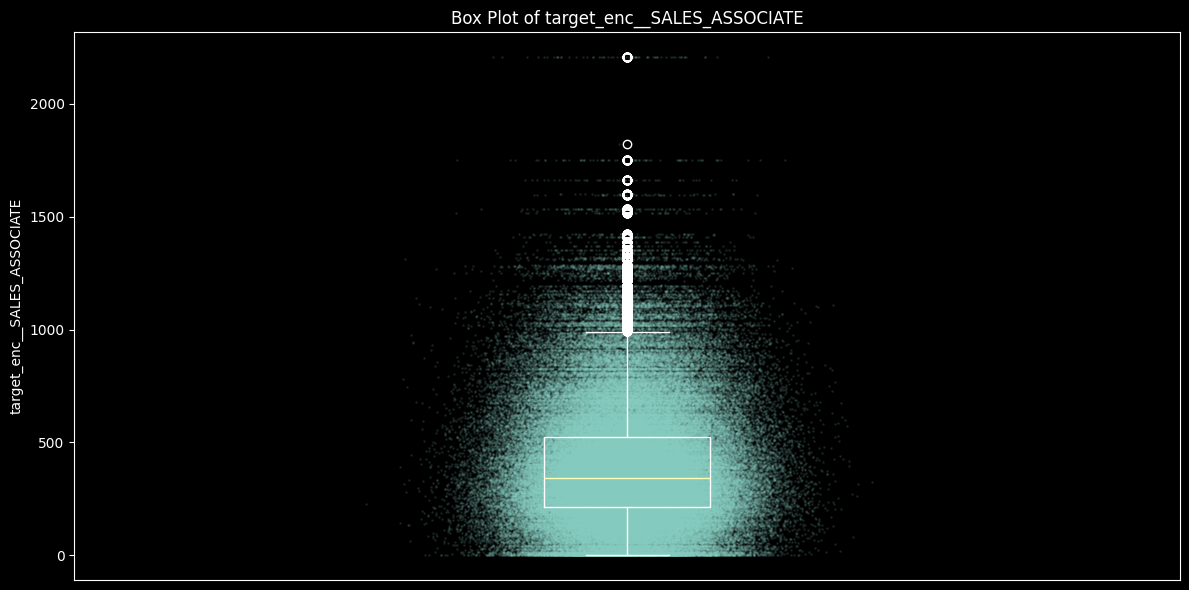

In [33]:
import numpy as np
plt.figure(figsize=(12, 6))
plt.boxplot(X_form['target_enc__SALES_ASSOCIATE'], vert=True)
plt.scatter(np.ones(len(X_form)) + np.random.normal(0, 0.05, len(X_form)), 
            X_form['target_enc__SALES_ASSOCIATE'], alpha=0.1, s=1)
plt.ylabel('target_enc__SALES_ASSOCIATE')
plt.title('Box Plot of target_enc__SALES_ASSOCIATE')
plt.xticks([])
plt.tight_layout()
plt.show()

In [34]:
records = X_form[X_form['target_enc__SALES_ASSOCIATE'] > 2000]

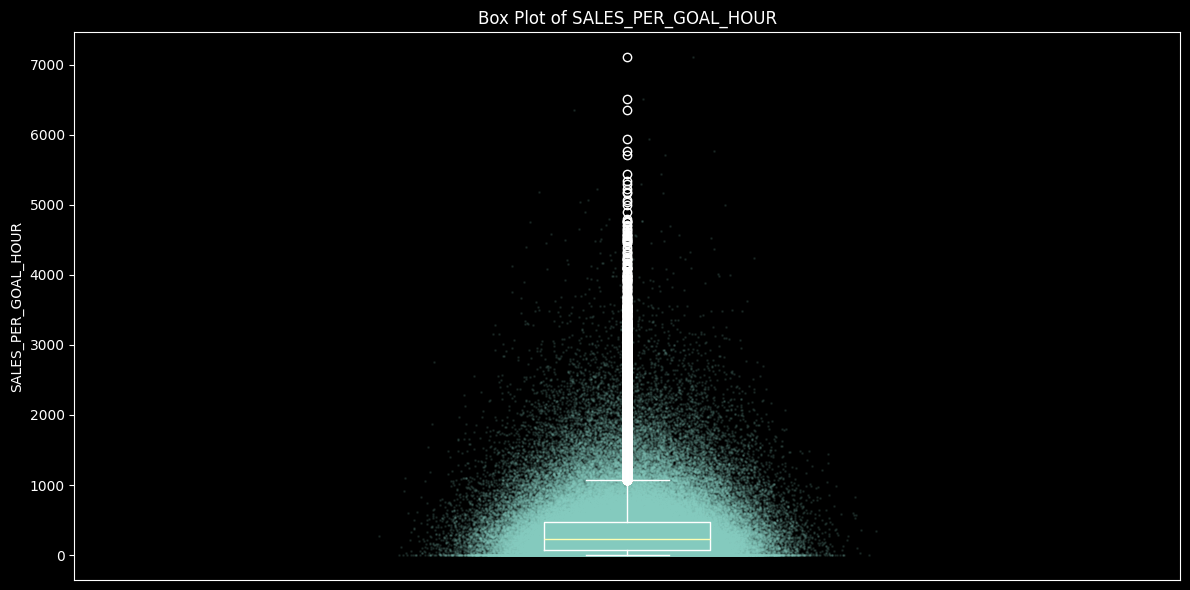

In [35]:
import numpy as np
plt.figure(figsize=(12, 6))
plt.boxplot(data['SALES_PER_GOAL_HOUR'], vert=True)
plt.scatter(np.ones(len(data)) + np.random.normal(0, 0.05, len(data)), 
            data['SALES_PER_GOAL_HOUR'], alpha=0.1, s=1)
plt.ylabel('SALES_PER_GOAL_HOUR')
plt.title('Box Plot of SALES_PER_GOAL_HOUR')
plt.xticks([])
plt.tight_layout()
plt.show()

In [36]:
# Calculate IQR for SALES_PER_GOAL_HOUR
q1 = data['SALES_PER_GOAL_HOUR'].quantile(0.25)
q3 = data['SALES_PER_GOAL_HOUR'].quantile(0.75)
iqr = q3 - q1
median = data['SALES_PER_GOAL_HOUR'].median()

print(f"SALES_PER_GOAL_HOUR IQR Analysis:")
print(f"Q1 (25th percentile): {q1:.2f}")
print(f"Median (50th percentile): {median:.2f}")
print(f"Q3 (75th percentile): {q3:.2f}")
print(f"IQR (Q3 - Q1): {iqr:.2f}")
print(f"\nOutlier bounds (using 1.5 * IQR):")
print(f"Lower bound: {q1 - 1.5 * iqr:.2f}")

print(f"Upper bound: {q3 + 1.5 * iqr:.2f}")

SALES_PER_GOAL_HOUR IQR Analysis:
Q1 (25th percentile): 68.54
Median (50th percentile): 230.27
Q3 (75th percentile): 470.95
IQR (Q3 - Q1): 402.41

Outlier bounds (using 1.5 * IQR):
Lower bound: -535.08
Upper bound: 1074.57


In [37]:
import shap

In [48]:
filtered_data = data[
    (data['BUSINESS_DATE'] == '2026-01-10') & 
    (data['STORE_NUMBER'] == '4002') 

]

In [49]:
filtered_data

,STORE_NUMBER,SALES_ASSOCIATE,BUSINESS_DATE,FINANCE_TEAM_GOAL,STORE_MANAGER_GOAL,LEGION_SCHEDULED_HOURS,GOALS_SCHEDULED_HOURS,GOAL,NET_SALES_AMOUNT_DLABS,GROSS_SALES_AMOUNT_DLABS,...,SALES_PER_GOAL_HOUR_32WKS,GOAL_ACHIEVEMENT_PCT_16WKS,SALES_PER_GOAL_HOUR_16WKS,GOAL_ACHIEVEMENT_PCT_8WKS,SALES_PER_GOAL_HOUR_8WKS,GOAL_ACHIEVEMENT_PCT_4WKS,SALES_PER_GOAL_HOUR_4WKS,GOAL_ACHIEVEMENT_PCT_2WKS,SALES_PER_GOAL_HOUR_2WKS,TENURE_BUCKET
264347,4002,467883,2026-01-10,92886.42,92886.42,7.75,4.84,2310.98,11.60,169.00,...,217.19520,-0.602292,217.19520,-0.555306,228.91000,-0.417928,326.18473,-0.850645,66.45600,>1.25
14563,4002,459564,2026-01-10,92886.42,92886.42,7.00,4.38,2087.34,753.50,753.50,...,267.91590,-0.527796,267.91590,-0.535819,268.07805,-0.498401,306.68736,-0.504889,256.41444,>1.25
155663,4002,753369,2026-01-10,92886.42,92886.42,8.25,8.25,3936.12,0.00,0.00,...,34.94200,-0.939431,34.94200,-0.945831,33.05034,-0.945247,29.35153,-0.914580,35.36375,0.50-0.75
13743,4002,761148,2026-01-10,92886.42,92886.42,5.50,5.50,2624.08,1755.70,1755.70,...,555.58294,-0.032335,555.58294,-0.032335,555.58294,0.071381,680.01916,0.272083,492.08600,0.25-0.50
151775,4002,457146,2026-01-10,92886.42,92886.42,7.75,4.84,2310.98,0.00,0.00,...,207.59409,-0.622268,207.59409,-0.599783,209.26000,-0.520833,307.92437,-0.725453,131.16166,>1.25
227264,4002,739004,2026-01-10,92886.42,92886.42,7.25,7.25,3459.01,541.30,740.30,...,674.84065,0.225359,674.84065,0.216006,677.81243,0.596674,933.49421,-0.144942,371.74500,1.00-1.25
226091,4002,753199,2026-01-10,92886.42,92886.42,6.75,6.75,3220.46,1775.00,1775.00,...,696.73114,0.116464,696.73114,0.138396,687.64900,0.201635,790.76266,-0.162812,520.50333,0.50-0.75
295277,4002,758320,2026-01-10,92886.42,92886.42,6.50,6.50,3101.18,1357.30,1357.30,...,330.09789,-0.486842,330.09789,-0.486842,330.09789,-0.464101,393.92454,-0.427569,342.73400,0.25-0.50
36661,4002,758116,2026-01-10,92886.42,92886.42,8.25,8.25,3936.12,-39.00,0.00,...,662.61400,0.276922,662.61400,0.276922,662.61400,-0.117862,493.13117,-0.237612,322.95625,0.25-0.50
131004,4002,557821,2026-01-10,92886.42,92886.42,8.00,5.00,2385.53,972.40,1425.40,...,582.77531,0.075037,582.77531,0.113630,576.26666,0.324203,745.45263,0.369794,613.88200,>1.25


In [40]:
# Filter data to Jan 10, store 4002, Associate 557821
filtered_data = data[
    (data['BUSINESS_DATE'] == '2026-01-10') & 
    (data['STORE_NUMBER'] == '4002') & 
    (data['SALES_ASSOCIATE'] == '467883')
]

In [41]:
filtered_data

,STORE_NUMBER,SALES_ASSOCIATE,BUSINESS_DATE,FINANCE_TEAM_GOAL,STORE_MANAGER_GOAL,LEGION_SCHEDULED_HOURS,GOALS_SCHEDULED_HOURS,GOAL,NET_SALES_AMOUNT_DLABS,GROSS_SALES_AMOUNT_DLABS,...,SALES_PER_GOAL_HOUR_32WKS,GOAL_ACHIEVEMENT_PCT_16WKS,SALES_PER_GOAL_HOUR_16WKS,GOAL_ACHIEVEMENT_PCT_8WKS,SALES_PER_GOAL_HOUR_8WKS,GOAL_ACHIEVEMENT_PCT_4WKS,SALES_PER_GOAL_HOUR_4WKS,GOAL_ACHIEVEMENT_PCT_2WKS,SALES_PER_GOAL_HOUR_2WKS,TENURE_BUCKET
264347,4002,467883,2026-01-10,92886.42,92886.42,7.75,4.84,2310.98,11.6,169.0,...,217.1952,-0.602292,217.1952,-0.555306,228.91,-0.417928,326.18473,-0.850645,66.456,>1.25


In [42]:
model.predict(filtered_data.drop(columns=[TARGET_COL]))

array([232.88453356])

In [43]:
filtered_X_form = model.named_steps['preprocessing'].transform(filtered_data.drop(columns=[TARGET_COL]))

In [44]:

explainer = shap.TreeExplainer(clf)

In [45]:
vals = explainer(filtered_X_form)

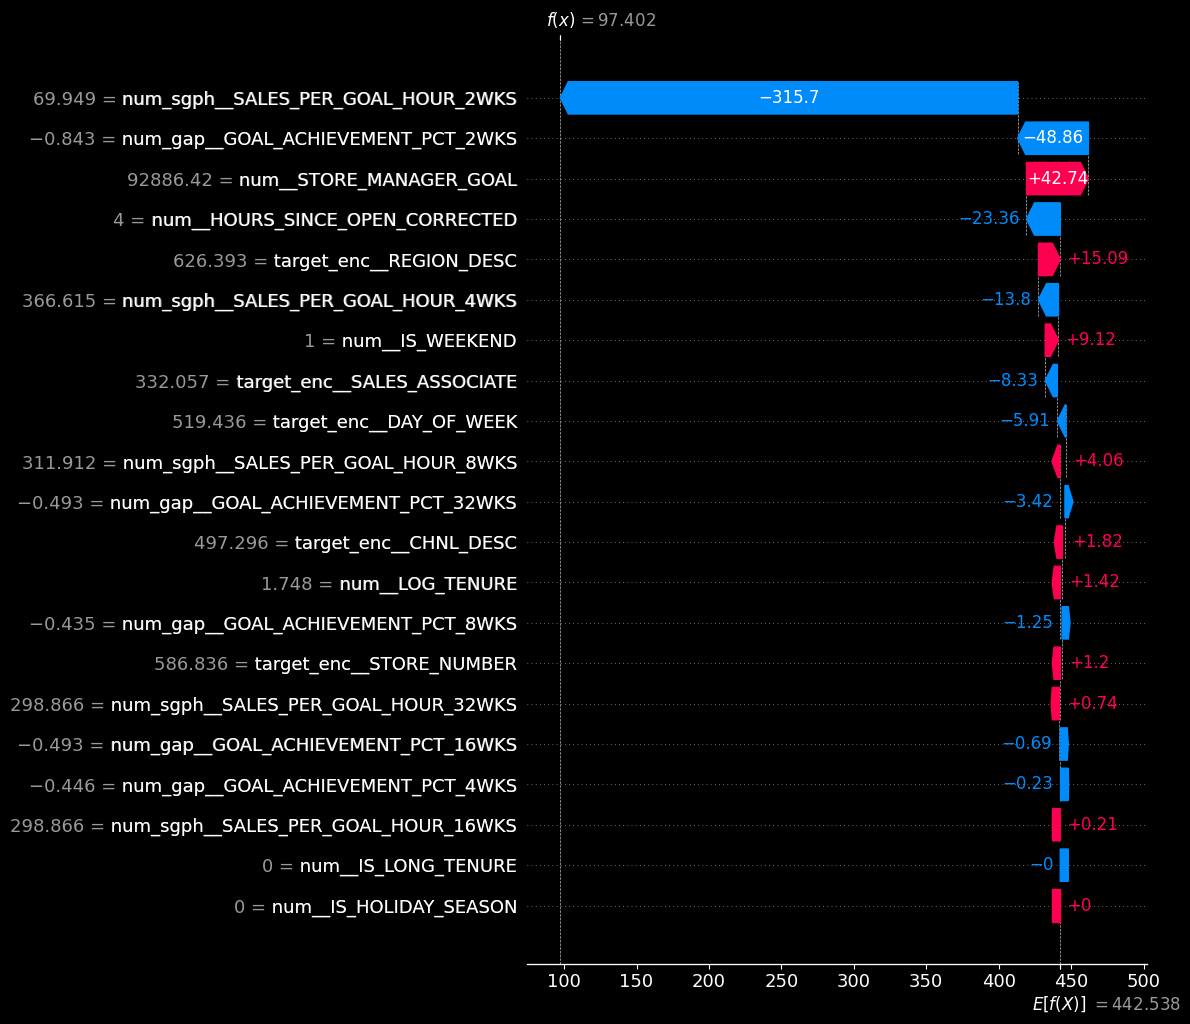

In [22]:
shap.plots.waterfall(vals[0], max_display=30)